<a href="https://colab.research.google.com/github/fbsilvaRP/ComputerVision-Fundamentals/blob/main/Pr%C3%A1tica02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
def show_images_playground(original, convolved, img_size):
  #Mostra as imagens original o resultado da convolução
  figure, axarr = plt.subplots(1, 2, figsize = (6, 6))
  axarr[0].imshow(original, cmap = 'gray')
  axarr[1].imshow(convolved, cmap = 'gray')
  for ax in axarr.ravel():
    #Configura major ticks
    ax.set_xticks(np.arange(0, img_size, 1))
    ax.set_yticks(np.arange(0, img_size, 1))
    #Configura minor ticks
    ax.set_xticks(np.arange(-.5, img_size, 1), minor = True)
    ax.set_yticks(np.arange(-.5, img_size, 1), minor = True)
    #Configura grindlines baseadas nos minor ticks
    ax.grid(which = 'minor', color = 'b', linestyle = '-', linewidth = 2)
    #remove minor ticks
    ax.tick_params(which = 'minor', bottom = False, left = False)
  plt.show()

def show_images(original, convolved):
  figure, axarr = plt.subplots(1, 2, figsize = (10, 10))
  axarr[0].imshow(original, cmap = 'gray')
  axarr[1].imshow(convolved, cmap = 'gray')

  #remove plt grid e ticks
  for ax in axarr.ravel():
    ax.set_axis_off()

  plt.show()


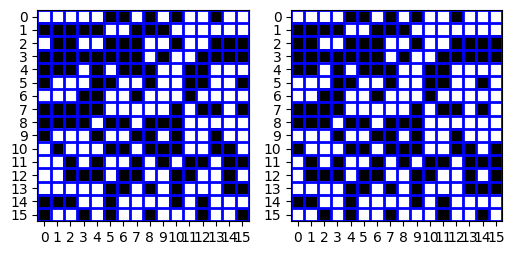

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlopen

SEED = 1234
np.random.seed(SEED)

#Criando uma imagem aleatória
img_size = 16
rnd_img = np.random.randint(0, 2, size = (img_size, img_size), dtype = np.uint8)

kernel = np.array(
    [[0, 0, 0],
     [0, 0, 1],
     [0, 0, 0]],
    np.float32)

resultado_img = cv2.filter2D(rnd_img, -1, kernel)
show_images_playground(rnd_img, resultado_img, img_size)



**Carregamento de Imagem**

In [12]:
def __pegaImagem__(url, readFlag = cv2.IMREAD_GRAYSCALE):
  resp = urlopen(url)
  image = np.asarray(bytearray(resp.read()), dtype = "uint8")
  image = cv2.imdecode(image, readFlag)
  image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
  return image

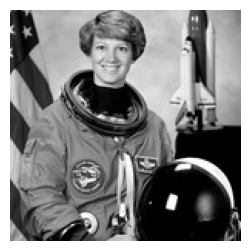

In [13]:
imagem = __pegaImagem__("https://www.flickr.com/photo_download.gne?id=16504233985&secret=9f1060624e&size=q&source=photoPageEngagement")

plt.figure(figsize = (3,3))
plt.imshow(imagem, cmap = "gray")
plt.axis("off")
plt.show()

**Filtro de média: Aplicação **

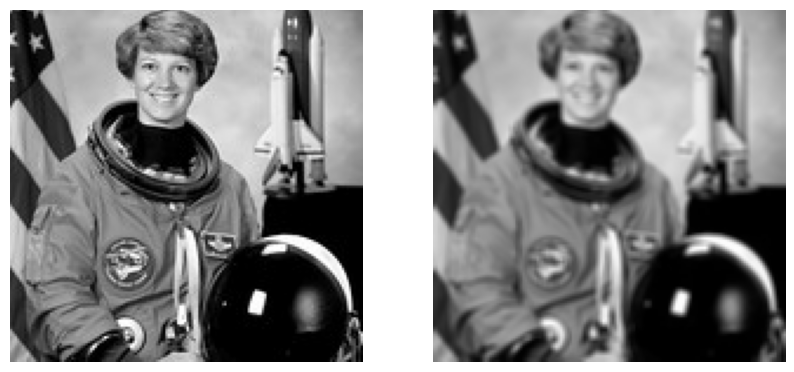

In [15]:
#define um kernel de suavização (média)
kernel = np.ones((3, 3), np.float32) / 9

#Aplica a convolução com o kernel
media_img = cv2.filter2D(imagem, -1, kernel)

show_images(imagem, media_img)